# Two-Stage Lang2Vec Clustering For High-Resource Languages

This notebook mirrors the clustering setup in `data_prep/lang_cluster_analysis/comprehensive_language_analysis_lang2vec.ipynb` but limits the analysis to the 200 languages with the highest number of documents in `fineweb2-language-distribution.csv`. After intersecting with Lang2Vec coverage we perform a silhouette sweep to pick the optimal number of clusters (genetic distances, average linkage), then visualize the resulting groups and inspect which clusters are farthest apart.


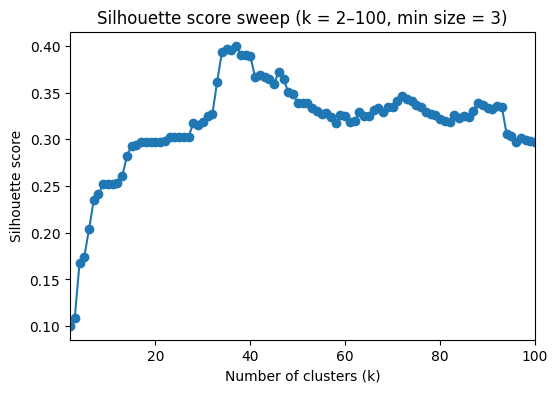

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


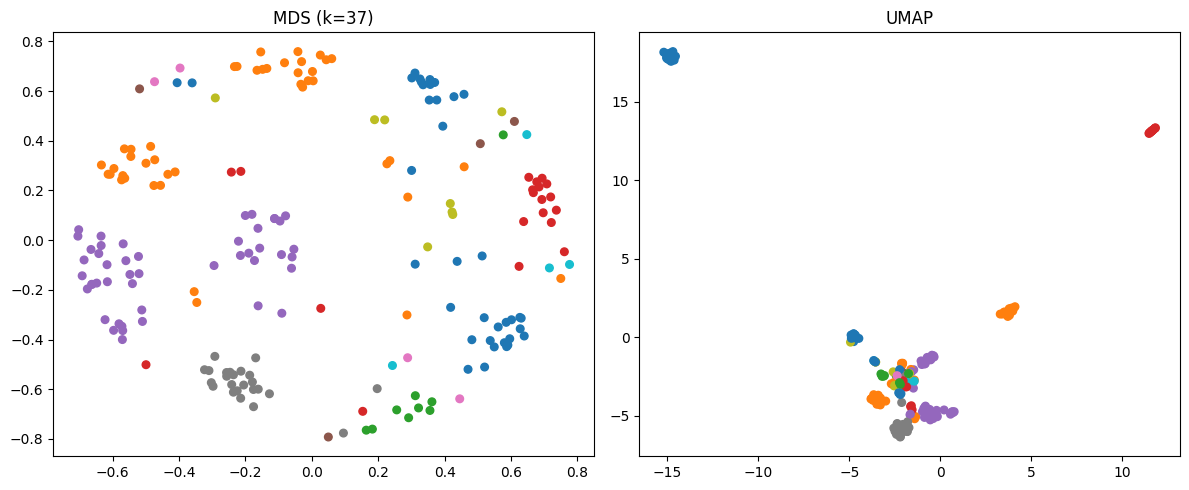

4 farthest clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(4)]


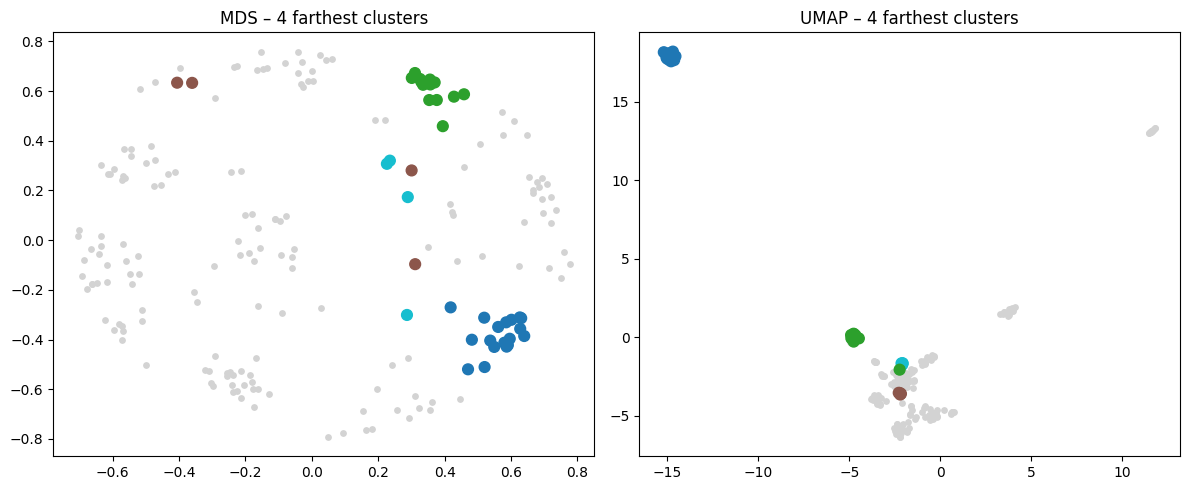

In [83]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.manifold import MDS
from cluster_lang2vec_distances import auto_k, build_distance_matrix, cluster_with_k
from lang2vec import lang2vec as l2v
import umap.umap_ as umap

# Load + filter
df = pd.read_csv("/home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/base_data/fineweb2-language-distribution.csv")
df = df[df.split == "train"]
df = df[~df.subset.str.contains("_removed$", na=False)]


top = (
    df.assign(documents=pd.to_numeric(df.documents, errors="coerce").fillna(0))
      .groupby(["code", "name", "family", "resource_availability"], as_index=False)
      ["documents"].sum()
      .sort_values("documents", ascending=False)
      .head(200)
)
langs = top[top.code.isin(l2v.DISTANCE_LANGUAGES)].reset_index(drop=True)
codes = langs.code.tolist()

matrix = build_distance_matrix(codes, "genetic")

# --- Silhouette sweep (keep original plot) ---
best_k, scores = auto_k(matrix, 2, 100, "average", min_cluster_size=1)
ks, vals = zip(*scores)

plt.figure(figsize=(6, 4))
plt.plot(ks, vals, marker="o")
plt.xlim(2, 100)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score sweep (k = 2–100, min size = 3)")
plt.show()

# cluster + mds plot + umap plot
labels = cluster_with_k(matrix, best_k, "average")
coords_mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0).fit_transform(matrix)
coords_umap = umap.UMAP(metric="precomputed", random_state=0).fit_transform(matrix)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c=labels, cmap="tab10", s=30)
ax[0].set_title(f"MDS (k={best_k})")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c=labels, cmap="tab10", s=30)
ax[1].set_title("UMAP")

plt.tight_layout()
plt.show()

# --- 4 farthest clusters with min size = 3 ---
clusters = {c: np.where(labels == c)[0] for c in set(labels)}
clusters = {c: idx for c, idx in clusters.items() if len(idx) >= 3}

pairs = [
    (a, b, matrix[np.ix_(ia, ib)].mean())
    for a, ia in clusters.items()
    for b, ib in clusters.items()
    if b > a
]

top_clusters = []
for a, b, _ in sorted(pairs, key=lambda x: x[2], reverse=True):
    for c in (a, b):
        if c not in top_clusters:
            top_clusters.append(c)
        if len(top_clusters) == 4:
            break
    if len(top_clusters) == 4:
        break

print("4 farthest clusters:", top_clusters)

# --- Highlight 4 farthest clusters: MDS + UMAP ---
mask = np.isin(labels, top_clusters)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
ax[0].scatter(coords_mds[mask, 0], coords_mds[mask, 1],
              c=labels[mask], cmap="tab10", s=60)
ax[0].set_title("MDS – 4 farthest clusters")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)
ax[1].scatter(coords_umap[mask, 0], coords_umap[mask, 1],
              c=labels[mask], cmap="tab10", s=60)
ax[1].set_title("UMAP – 4 farthest clusters")

plt.tight_layout()
plt.show()



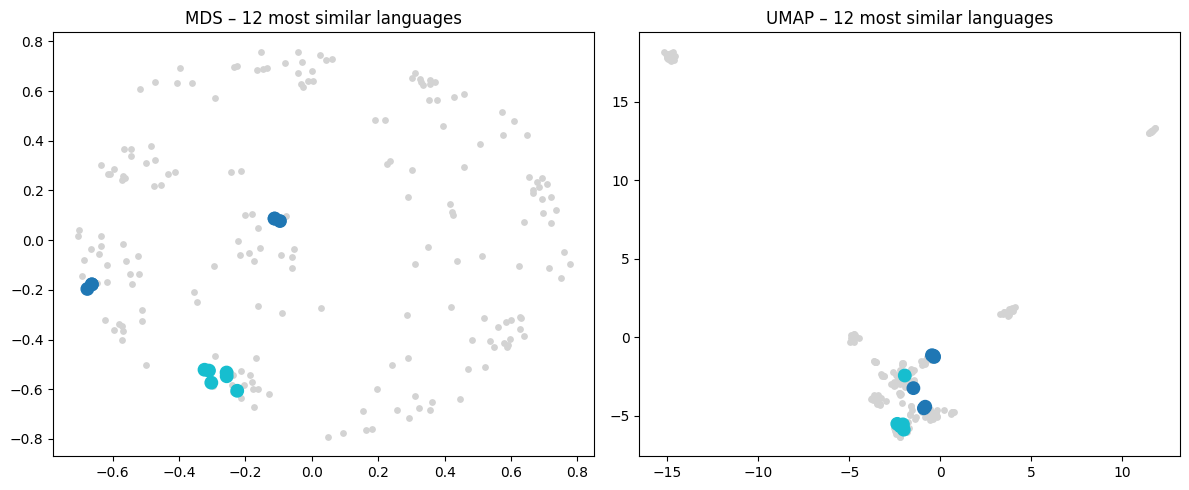

code resource_availability   subset
 bos                   LOW bos_Latn
 fur                   LOW fur_Latn
 hin                MEDIUM hin_Deva
 hin                   NaN hin_Latn
 ita                  HIGH ita_Latn
 nap                   LOW nap_Latn
 roh                   LOW roh_Latn
 scn                   LOW scn_Latn
 srp                MEDIUM srp_Cyrl
 srp                   LOW srp_Latn
 urd                MEDIUM urd_Arab
 urd                   LOW urd_Latn
 wln                   LOW wln_Latn


In [78]:
# alternative without clustering + expert separation

from itertools import combinations

n = matrix.shape[0]
used = set()
experts = []

def inter_dist(A, B):
    return matrix[np.ix_(list(A), list(B))].mean()

candidates = sorted(
    ((a, b, c,
      (matrix[a,b] + matrix[a,c] + matrix[b,c]) / 3)
     for a, b, c in combinations(range(n), 3)),
    key=lambda x: x[3]  # internal similarity
)

for a, b, c, _ in candidates:
    triple = {a, b, c}
    if triple & used:
        continue
    if experts and min(inter_dist(triple, set(t)) for t in experts) < 0.3:
        continue
    experts.append((a, b, c))
    used |= triple
    if len(experts) == 4:
        break

final_langs = np.array([i for t in experts for i in t])



mask = np.isin(np.arange(len(labels)), final_langs)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
ax[0].scatter(coords_mds[mask, 0], coords_mds[mask, 1],
              c=labels[mask], cmap="tab10", s=80)
ax[0].set_title("MDS – 12 most similar languages")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)
ax[1].scatter(coords_umap[mask, 0], coords_umap[mask, 1],
              c=labels[mask], cmap="tab10", s=80)
ax[1].set_title("UMAP – 12 most similar languages")

plt.tight_layout()
plt.show()


selected_codes = [codes[i] for i in final_langs]

# lookup in original CSV
info = (
    df.loc[df.code.isin(selected_codes),
           ["code", "resource_availability", "subset"]]
      .drop_duplicates()
      .sort_values("code")
)

print(info.to_string(index=False))

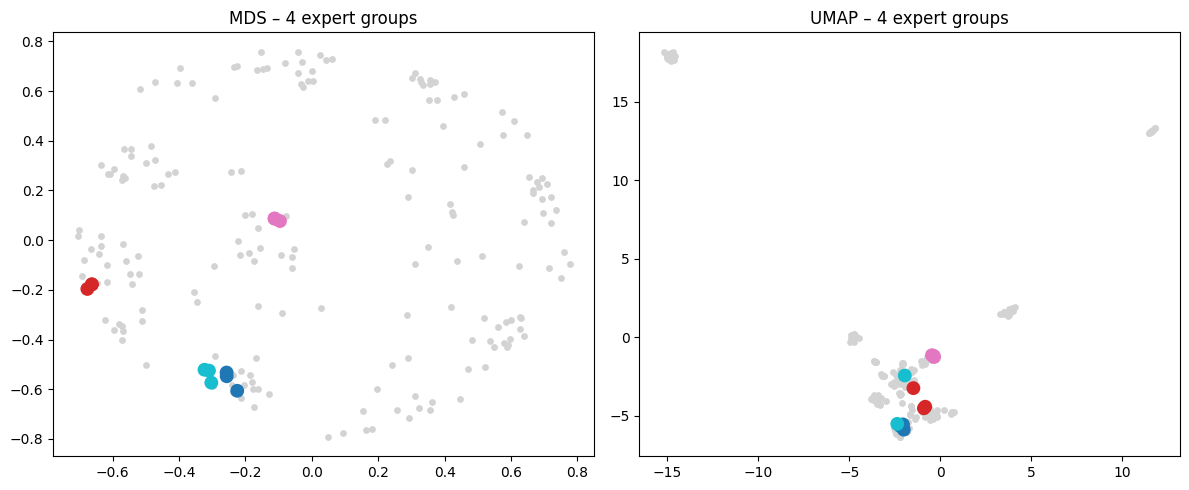

code       name        family resource_availability
 bos    Bosnian Indo-European                   LOW
 fur   Friulian Indo-European                   LOW
 hin      Hindi Indo-European                MEDIUM
 hin      Hindi Indo-European                   NaN
 ita    Italian Indo-European                  HIGH
 nap Neapolitan Indo-European                   LOW
 roh    Romansh Indo-European                   LOW
 scn   Sicilian Indo-European                   LOW
 srp    Serbian Indo-European                MEDIUM
 srp    Serbian Indo-European                   LOW
 urd       Urdu Indo-European                MEDIUM
 urd       Urdu Indo-European                   LOW
 wln    Walloon Indo-European                   LOW


In [82]:
from itertools import combinations

n = matrix.shape[0]
used = set()
experts = []

def inter_dist(A, B):
    return matrix[np.ix_(list(A), list(B))].mean()

for a, b, c, _ in sorted(
    ((a, b, c,
      (matrix[a,b] + matrix[a,c] + matrix[b,c]) / 3)
     for a, b, c in combinations(range(n), 3)),
    key=lambda x: x[3]
):
    triple = {a, b, c}
    if triple & used:
        continue
    if experts and min(inter_dist(triple, set(t)) for t in experts) < 0.35:
        continue
    experts.append((a, b, c))
    used |= triple
    if len(experts) == 4:
        break


final_langs = np.array([i for t in experts for i in t])


mask = np.isin(np.arange(len(codes)), final_langs)

# label expert id per language
expert_id = np.full(len(codes), -1)
for i, t in enumerate(experts):
    for j in t:
        expert_id[j] = i

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(coords_mds[:, 0], coords_mds[:, 1], c="lightgray", s=15)
ax[0].scatter(coords_mds[expert_id >= 0, 0],
              coords_mds[expert_id >= 0, 1],
              c=expert_id[expert_id >= 0],
              cmap="tab10", s=80)
ax[0].set_title("MDS – 4 expert groups")

ax[1].scatter(coords_umap[:, 0], coords_umap[:, 1], c="lightgray", s=15)
ax[1].scatter(coords_umap[expert_id >= 0, 0],
              coords_umap[expert_id >= 0, 1],
              c=expert_id[expert_id >= 0],
              cmap="tab10", s=80)
ax[1].set_title("UMAP – 4 expert groups")

plt.tight_layout()
plt.show()


# print which langs we selected
selected_codes = [codes[i] for i in final_langs]

info = (
    df.loc[df.code.isin(selected_codes),
           ["code", "name", "family", "resource_availability"]]
      .drop_duplicates()
      .sort_values("code")
)

print(info.to_string(index=False))
